# Check parquet integrity

The following notebook explores the metadata parquet created by build_metadata_table.py. Much of the following EDA relates to confirming joining logic and ensuring results are as expected. Finally, a cleaned dataframe is created. Also note that the following performs site/field-level embeddings, not well-level embeddings.

In [1]:
import pandas as pd
import numpy as np

# Load data
PATH = "../data/processed/master_metadata.parquet"
df = pd.read_parquet(PATH)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (864, 44)

Columns:
 ['url_origdna', 'url_origlowzbf', 'url_orighighzbf', 'url_origbrightfield', 'url_origmito', 'url_origagp', 'url_origer', 'url_origrna', 'plate', 'well', 'site', 'metadata_abspositionz', 'metadata_abstime', 'metadata_binningx', 'metadata_binningy', 'metadata_channelid', 'metadata_channelname', 'metadata_col', 'metadata_exposuretime', 'metadata_fieldid', 'metadata_imageresolutionx', 'metadata_imageresolutiony', 'metadata_imagesizex', 'metadata_imagesizey', 'metadata_mainemissionwavelength', 'metadata_mainexcitationwavelength', 'metadata_maxintensity', 'metadata_objectivemagnification', 'metadata_objectivena', 'metadata_planeid', 'metadata_positionx', 'metadata_positiony', 'metadata_positionz', 'metadata_row', 'broad_sample', 'solvent', 'InChIKey', 'pert_iname', 'pubchem_cid', 'gene', 'pert_type', 'control_type', 'smiles', 'image_paths']


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864 entries, 0 to 863
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   url_origdna                        864 non-null    object 
 1   url_origlowzbf                     864 non-null    object 
 2   url_orighighzbf                    864 non-null    object 
 3   url_origbrightfield                864 non-null    object 
 4   url_origmito                       864 non-null    object 
 5   url_origagp                        864 non-null    object 
 6   url_origer                         864 non-null    object 
 7   url_origrna                        864 non-null    object 
 8   plate                              864 non-null    object 
 9   well                               864 non-null    object 
 10  site                               864 non-null    int64  
 11  metadata_abspositionz              864 non-null    float64

In [3]:
df.head(20)

,url_origdna,url_origlowzbf,url_orighighzbf,url_origbrightfield,url_origmito,url_origagp,url_origer,url_origrna,plate,well,...,broad_sample,solvent,InChIKey,pert_iname,pubchem_cid,gene,pert_type,control_type,smiles,image_paths
0,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,None,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,[raw/images/BR00116991/r01c01f01p01-ch1sk1fk1f...
1,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,None,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,[raw/images/BR00116991/r01c01f02p01-ch1sk1fk1f...
2,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,None,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,[raw/images/BR00116991/r01c01f03p01-ch1sk1fk1f...
3,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,None,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,[raw/images/BR00116991/r01c01f04p01-ch1sk1fk1f...
4,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,None,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,[raw/images/BR00116991/r01c01f05p01-ch1sk1fk1f...
5,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,BR00116991,A01,...,BRD-A86665761-001-01-1,DMSO,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883933.0,CACNB4,trt,None,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,[raw/images/BR00116991/r01c01f06p01-ch1sk1fk1f...
6,s3://cellpainting-gallery/cpg0000-jump-pilot/s...,s3://cellpainting-gallery/cpg00

In [4]:
# Check missing values
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(20))

control_type                         0.635417
gene                                 0.177083
broad_sample                         0.177083
pubchem_cid                          0.031250
url_origdna                          0.000000
metadata_positiony                   0.000000
metadata_mainemissionwavelength      0.000000
metadata_mainexcitationwavelength    0.000000
metadata_maxintensity                0.000000
metadata_objectivemagnification      0.000000
metadata_objectivena                 0.000000
metadata_planeid                     0.000000
metadata_positionx                   0.000000
metadata_row                         0.000000
metadata_positionz                   0.000000
url_origlowzbf                       0.000000
solvent                              0.000000
InChIKey                             0.000000
pert_iname                           0.000000
pert_type                            0.000000
dtype: float64


Note - image missingness due to only downloading subset of rows from plate

In [5]:
# Show treatment counts
if "pert_type" in df.columns:
    print("\npert_type distribution:")
    print(df["pert_type"].value_counts())

if "broad_sample" in df.columns:
    print("\nunique compounds:", df["broad_sample"].nunique())


pert_type distribution:
pert_type
trt        549
control    315
Name: count, dtype: int64

unique compounds: 76


In [6]:
# Print compounds with images count
if "broad_sample" in df.columns:
    print("compounds with images:",
          df[df["image_paths"].notna()]["broad_sample"].nunique())

compounds with images: 76


In [7]:
# Check unique sites per well
if "site" in df.columns:
    print(df.groupby("well")["site"].nunique().describe())

count    96.0
mean      9.0
std       0.0
min       9.0
25%       9.0
50%       9.0
75%       9.0
max       9.0
Name: site, dtype: float64


In [8]:
# Confirm no missing plates/wells
assert df["plate"].notna().all(), "Missing plate values!"
assert df["well"].notna().all(), "Missing well values!"

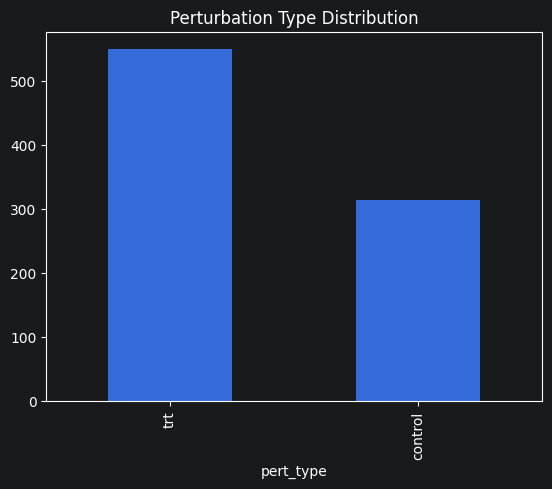

In [9]:
# Show perturbation type distribution
import matplotlib.pyplot as plt

df["pert_type"].value_counts().plot(kind="bar")
plt.title("Perturbation Type Distribution")
plt.show()

# EDA of parquet

In [10]:
# Descriptive stats
print("Unique plates:", df["plate"].nunique())
print("Unique wells:", df["well"].nunique())
print("Unique sites:", df["site"].nunique())

print("\nRows per plate:")
print(df.groupby("plate").size())

print("\nSites per well:")
print(df.groupby(["plate", "well"])["site"].nunique().describe())

Unique plates: 1
Unique wells: 96
Unique sites: 9

Rows per plate:
plate
BR00116991    864
dtype: int64

Sites per well:
count    96.0
mean      9.0
std       0.0
min       9.0
25%       9.0
50%       9.0
75%       9.0
max       9.0
Name: site, dtype: float64


In [11]:
# Print compound counts
compound_counts = (
    df.groupby("broad_sample")
    .size()
    .sort_values(ascending=False)
)

print(compound_counts.head(20))

print("\nMedian rows per compound:")
print(compound_counts.median())

broad_sample
BRD-K38852836-001-04-9    18
BRD-K64890080-001-02-1    18
BRD-K64800655-001-09-0    18
BRD-K54330070-001-19-6     9
BRD-K67637637-003-11-8     9
BRD-K64054020-001-02-7     9
BRD-K63430059-001-16-4     9
BRD-K61845293-300-01-9     9
BRD-K57708067-001-01-3     9
BRD-K52960356-001-13-0     9
BRD-K47049295-300-03-1     9
BRD-K52075715-001-06-7     9
BRD-K50720187-051-03-1     9
BRD-K50498985-001-03-3     9
BRD-K50199947-001-03-4     9
BRD-K48278478-001-01-2     9
BRD-K47598052-001-14-1     9
BRD-K47557313-001-02-7     9
BRD-K67915505-001-01-2     9
BRD-A01078468-001-14-8     9
dtype: int64

Median rows per compound:
9.0


In [12]:
# Print gene counts
gene_counts = (
    df.groupby("gene")
    .size()
    .sort_values(ascending=False)
)

print(gene_counts.head(20))

print("\nUnique genes:", df["gene"].nunique())
print("Median rows per gene:", gene_counts.median())

gene
HPGDS       18
CA5A        18
MAPK8       18
PLK1        18
PNLIP       18
CDK7        18
NTRK1       18
CACNA2D3    18
KCNJ1       18
BAX         18
GAA         18
HSP90AA1    18
IL1B         9
ICAM1        9
KCNMA1       9
KCNN4        9
KCNQ2        9
LCK          9
HSP90AB1     9
MAPK14       9
dtype: int64

Unique genes: 67
Median rows per gene: 9.0


In [13]:
# Print controls
print(df["control_type"].value_counts(dropna=False))
print("\nTreatment vs controls:")
print(df["pert_type"].value_counts(dropna=False))

control_type
None              549
negcon            153
poscon_diverse     99
poscon_cp          54
poscon_orf          9
Name: count, dtype: int64

Treatment vs controls:
pert_type
trt        549
control    315
Name: count, dtype: int64


In [14]:
# Show image coverage
image_coverage = (
    df.groupby("well")["image_paths"]
    .apply(lambda x: x.notna().mean())
)

print(image_coverage.describe())

count    96.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: image_paths, dtype: float64


In [15]:
# Show rows missing images
missing_images = df[df["image_paths"].isna()]
print("Rows missing images:", len(missing_images))

#if len(missing_images) > 0:
missing_images[
    ["plate", "well", "site", "broad_sample", "image_paths"]
].head(20)

Rows missing images: 0


,plate,well,site,broad_sample,image_paths


In [18]:
# Confirm consistent image sizes
print(df["metadata_imagesizex"].value_counts())
print(df["metadata_imagesizey"].value_counts())

metadata_imagesizex
1080    864
Name: count, dtype: int64
metadata_imagesizey
1080    864
Name: count, dtype: int64


In [19]:
# Show duplicate biological-image rows
print(df.duplicated(["plate", "well", "site"]).sum()) # 864
df.groupby(["plate", "well", "site"]).size().describe()

0


count    864.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64

In [20]:
# Show sample image paths
sample = df[df["image_paths"].notna()].sample(5)

for _, row in sample.iterrows():
    print("\nWELL:", row["well"])
    print("SITE:", row["site"])
    print("IMAGE PATHS:")
    print(row["image_paths"])


WELL: I22
SITE: 5
IMAGE PATHS:
['raw/images/BR00116991/r09c22f05p01-ch1sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c22f05p01-ch2sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c22f05p01-ch3sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c22f05p01-ch4sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c22f05p01-ch5sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c22f05p01-ch6sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c22f05p01-ch7sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c22f05p01-ch8sk1fk1fl1.tiff']

WELL: I12
SITE: 2
IMAGE PATHS:
['raw/images/BR00116991/r09c12f02p01-ch1sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c12f02p01-ch2sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c12f02p01-ch3sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c12f02p01-ch4sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c12f02p01-ch5sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c12f02p01-ch6sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c12f02p01-ch7sk1fk1fl1.tiff'
 'raw/images/BR00116991/r09c12f02p01-ch8sk1fk1fl1.tiff']

WELL: A15
SITE: 9
IMAGE PATHS:
['raw/

# Preprocessing

In [21]:
keep_cols = [
    "image_paths",
    "plate",
    "well",
    "site",
    "broad_sample",
    "pert_iname",
    "pert_type",
    "control_type",
    "gene",
    "smiles",
    "InChIKey",
]
clean_df = df[keep_cols].copy()
clean_df.head(20)

,image_paths,plate,well,site,broad_sample,pert_iname,pert_type,control_type,gene,smiles,InChIKey
0,[raw/images/BR00116991/r01c01f01p01-ch1sk1fk1f...,BR00116991,A01,1,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,None,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
1,[raw/images/BR00116991/r01c01f02p01-ch1sk1fk1f...,BR00116991,A01,2,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,None,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
2,[raw/images/BR00116991/r01c01f03p01-ch1sk1fk1f...,BR00116991,A01,3,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,None,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
3,[raw/images/BR00116991/r01c01f04p01-ch1sk1fk1f...,BR00116991,A01,4,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,None,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
4,[raw/images/BR00116991/r01c01f05p01-ch1sk1fk1f...,BR00116991,A01,5,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,None,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
5,[raw/images/BR00116991/r01c01f06p01-ch1sk1fk1f...,BR00116991,A01,6,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,None,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
6,[raw/images/BR00116991/r01c01f07p01-ch1sk1fk1f...,BR00116991,A01,7,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,None,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
7,[raw/images/BR00116991/r01c01f08p01-ch1sk1fk1f...,BR00116991,A01,8,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,None,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
8,[raw/images/BR00116991/r01c01f09p01-ch1sk1fk1f...,BR00116991,A01,9,BRD-A86665761-001-01-1,gabapentin-enacarbil,trt,None,CACNB4,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,TZDUHAJSIBHXDL-UHFFFAOYSA-N
9,[raw/images/BR00116991/r01c02f01p01-ch1sk1fk1f...,BR00116991,A02,1,None,DMSO,control,negcon,None,CS(=O)C,IAZDPXIOMUYVGZ-UHFFFAOYSA-N
